In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
from impl.utils.explain import vectorize, generate_rules, evaluate_rules, model_fit, explain, scoring

In [2]:
import pickle
from pathlib import Path

projects = [
    "1748904187579-rs-eb1239", "1748957118058-rs-2e552d", "1749004788416-rs-6bf5f1", "1749054600895-rs-2ed24b",
    "1749101043616-rs-24f811", "1749789337635-rs-395f0a", "1749825433865-rs-6f42c1", "1749852996207-rs-73049d",
    "1749897744564-rs-122ef9", "1749934847144-rs-a62c00",
    "1750024619112-ccea-c17eea", "1750035311708-ccea-bc1e43", "1750046040692-ccea-b4928e", "1750056485911-ccea-b080ee",
    "1750067278236-ccea-219341", "1750079630954-ccea-5d7aef", "1750098720114-ccea-5a34ee", "1750110774781-ccea-3fab0c",
    "1750119440223-ccea-6fdbce", "1750130885536-ccea-29f180", "1750143528961-ccea-d9feb9", "1750155121239-ccea-b387ef",
    "1750165607737-ccea-002db1", "1750177521170-ccea-3113cf", "1750294960102-ccea-bea9a9", "1750306696960-ccea-cd237d",
    "1750316836587-ccea-7e88f8", "1750327777071-ccea-08b810", "1750338408155-ccea-ec2e49", "1750345341498-ccea-68f114",
    "1750358095278-ccea-af744a", "1750368163929-ccea-c002db", "1750379514014-ccea-878e8f", "1750391767572-ccea-000287",
    "1750433269030-ccea-ea150e", "1750185618111-ccea-6e8d47", "1750198943587-ccea-7053fc", "1750206690539-ccea-5685b2",
    "1750216454876-ccea-7d20e2", "1750227193443-ccea-78d6d1", "1750239856908-ccea-022c28", "1750251392201-ccea-cf8492",
    "1750264266398-ccea-6050fe", "1750268611439-ccea-719936", "1750277989099-ccea-b24329",
]

violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
print(len(violations), len(non_violations))
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(len(solutions))

451 258
709


In [3]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

2025-06-27 12:08:56,241     INFO  2641635 --- 
COMPREHENSIVE GRID SEARCH
================================================== (explain.py:110)
2025-06-27 12:08:56,243     INFO  2641635 --- Testing 3888 parameter combinations... (explain.py:141)
2025-06-27 12:08:56,244     INFO  2641635 --- Starting grid search... (explain.py:153)
Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


tostring() is deprecated. Use tobytes() instead.


2025-06-27 12:16:09,690     INFO  2641635 --- Grid search completed! (explain.py:156)
2025-06-27 12:16:09,692     INFO  2641635 --- Best CV RMSE: 0.917883 (explain.py:157)
2025-06-27 12:16:09,692     INFO  2641635 --- 
Best parameters:
	alpha               : 0.1
	learning_rate       : 0.01
	max_depth           : 8
	max_features        : log2
	min_samples_leaf    : 1
	min_samples_split   : 2
	n_estimators        : 50
	subsample           : 0.9 (explain.py:161)
2025-06-27 12:16:09,692     INFO  2641635 --- 
GRID SEARCH ANALYSIS
================================================== (explain.py:163)
2025-06-27 12:16:09,700     INFO  2641635 --- 
Top 5 parameter combinations:
	1. RMSE: 0.917883 - {'alpha': 0.1, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.9}
	2. RMSE: 0.917883 - {'alpha': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_spli

tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprec

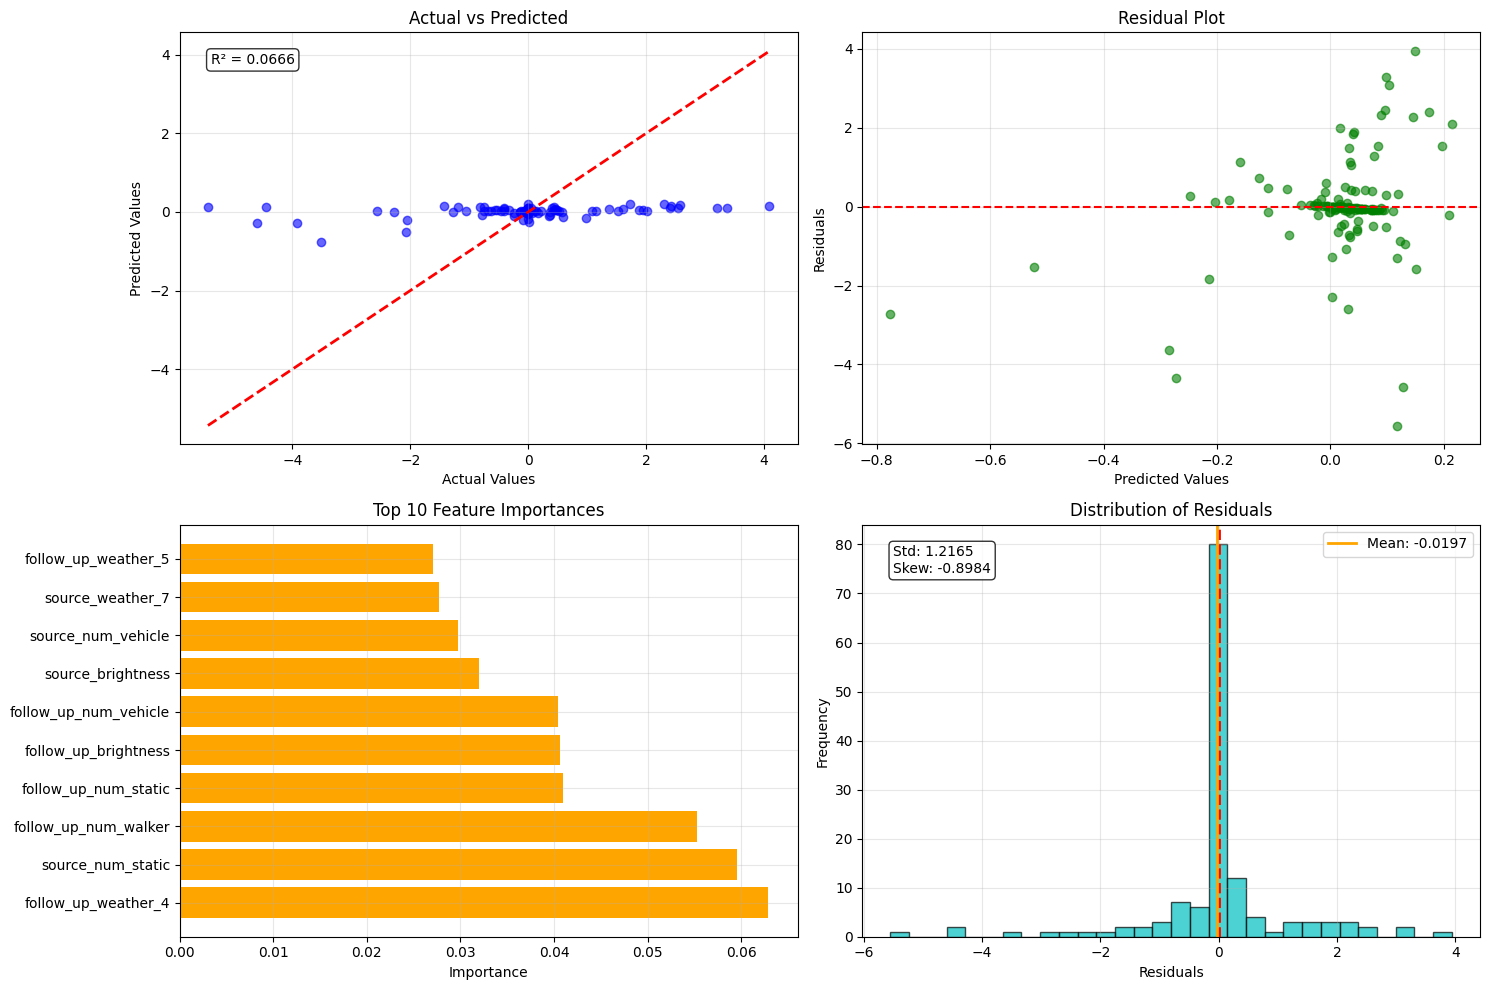

In [5]:
best_model = model_fit(X, y)

2025-06-27 12:18:54,892     INFO  2641635 --- 
COMPREHENSIVE GRID SEARCH
================================================== (explain.py:110)
2025-06-27 12:18:54,893     INFO  2641635 --- Testing 3888 parameter combinations... (explain.py:141)
2025-06-27 12:18:54,894     INFO  2641635 --- Starting grid search... (explain.py:153)
Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


tostring() is deprecated. Use tobytes() instead.


2025-06-27 12:25:55,579     INFO  2641635 --- Grid search completed! (explain.py:156)
2025-06-27 12:25:55,580     INFO  2641635 --- Best CV RMSE: 0.751602 (explain.py:157)
2025-06-27 12:25:55,581     INFO  2641635 --- 
Best parameters:
	alpha               : 0.1
	learning_rate       : 0.01
	max_depth           : 8
	max_features        : 0.8
	min_samples_leaf    : 1
	min_samples_split   : 2
	n_estimators        : 50
	subsample           : 0.8 (explain.py:161)
2025-06-27 12:25:55,582     INFO  2641635 --- 
GRID SEARCH ANALYSIS
================================================== (explain.py:163)
2025-06-27 12:25:55,587     INFO  2641635 --- 
Top 5 parameter combinations:
	1. RMSE: 0.751602 - {'alpha': 0.1, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50, 'subsample': 0.8}
	2. RMSE: 0.751602 - {'alpha': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 0.8, 'min_samples_leaf': 1, 'min_samples_split': 2, 

tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.


2025-06-27 12:25:55,905     INFO  2641635 --- ✓ Grid search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1751041555795/grid_search_results.pkl'. (explain.py:218)
2025-06-27 12:25:55,906     INFO  2641635 --- 
MODEL VISUALIZATION
================================================== (explain.py:220)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprec

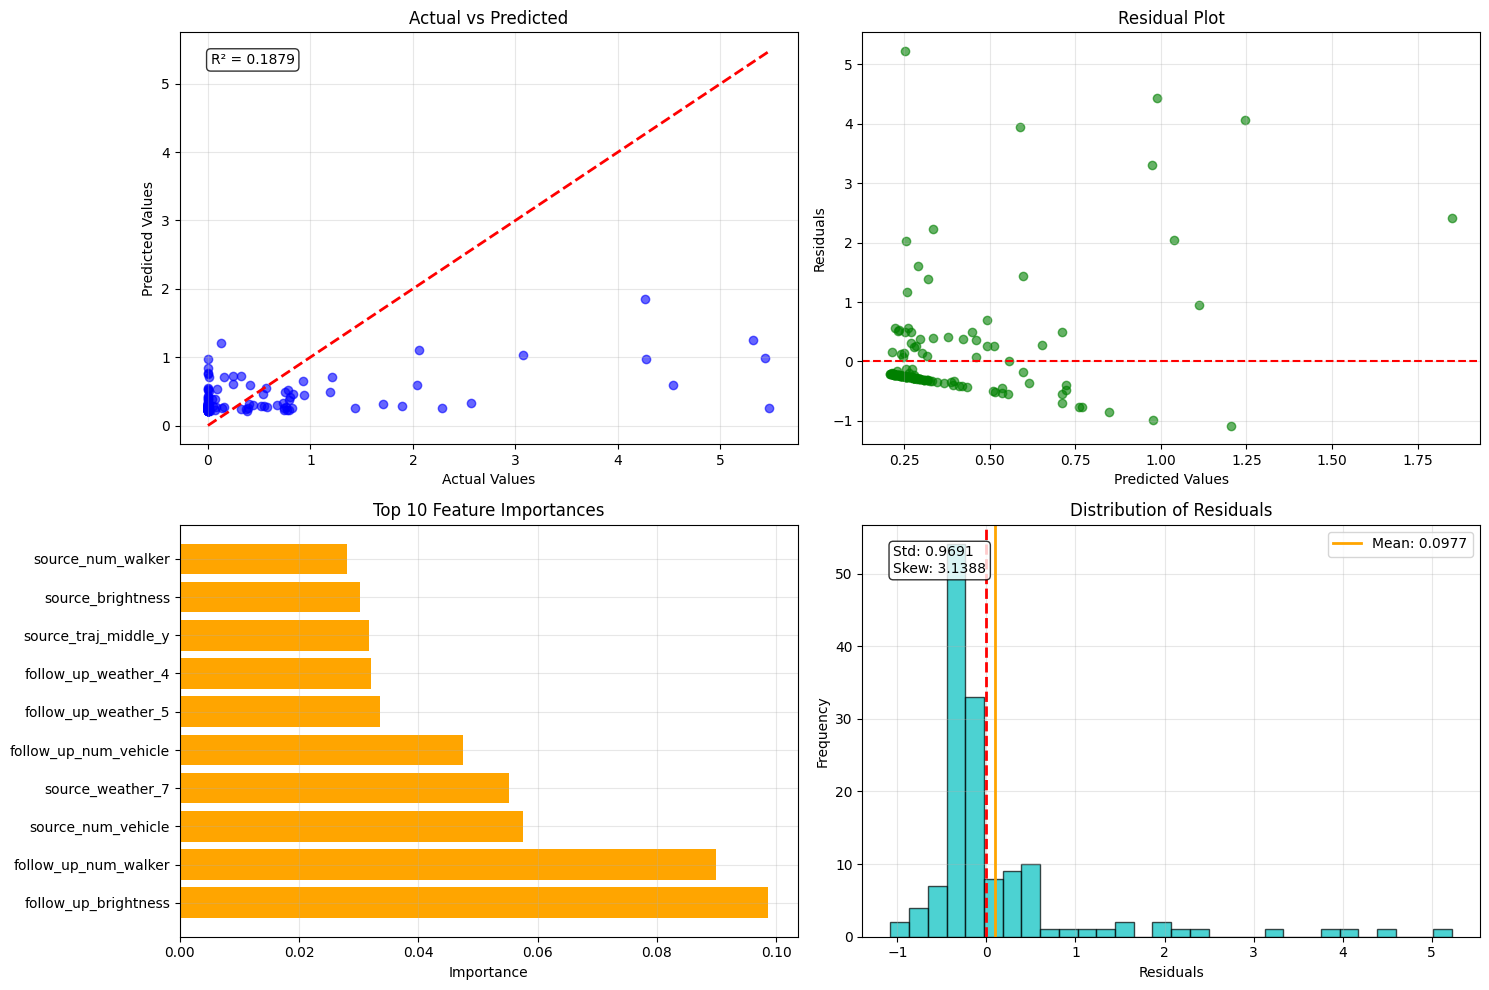

In [6]:
best_model_v1 = model_fit(X, y_v1)

2025-06-27 12:26:46,649     INFO  2641635 --- 
COMPREHENSIVE GRID SEARCH
================================================== (explain.py:110)
2025-06-27 12:26:46,650     INFO  2641635 --- Testing 3888 parameter combinations... (explain.py:141)
2025-06-27 12:26:46,651     INFO  2641635 --- Starting grid search... (explain.py:153)
Fitting 5 folds for each of 3888 candidates, totalling 19440 fits


tostring() is deprecated. Use tobytes() instead.


2025-06-27 12:34:28,654     INFO  2641635 --- Grid search completed! (explain.py:156)
2025-06-27 12:34:28,655     INFO  2641635 --- Best CV RMSE: 0.806642 (explain.py:157)
2025-06-27 12:34:28,656     INFO  2641635 --- 
Best parameters:
	alpha               : 0.1
	learning_rate       : 0.01
	max_depth           : 8
	max_features        : 1.0
	min_samples_leaf    : 4
	min_samples_split   : 10
	n_estimators        : 50
	subsample           : 0.8 (explain.py:161)
2025-06-27 12:34:28,656     INFO  2641635 --- 
GRID SEARCH ANALYSIS
================================================== (explain.py:163)
2025-06-27 12:34:28,662     INFO  2641635 --- 
Top 5 parameter combinations:
	1. RMSE: 0.806642 - {'alpha': 0.1, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50, 'subsample': 0.8}
	2. RMSE: 0.806642 - {'alpha': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'max_features': 1.0, 'min_samples_leaf': 4, 'min_samples_split': 1

tostring() is deprecated. Use tobytes() instead.


2025-06-27 12:34:28,927     INFO  2641635 --- Cross-validation RMSE: 0.806642 (+/- 0.530067) (explain.py:206)
2025-06-27 12:34:28,933     INFO  2641635 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1751042068929/best_model.pkl'. (explain.py:213)
2025-06-27 12:34:29,057     INFO  2641635 --- ✓ Grid search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1751042068929/grid_search_results.pkl'. (explain.py:218)
2025-06-27 12:34:29,058     INFO  2641635 --- 
MODEL VISUALIZATION
================================================== (explain.py:220)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprec

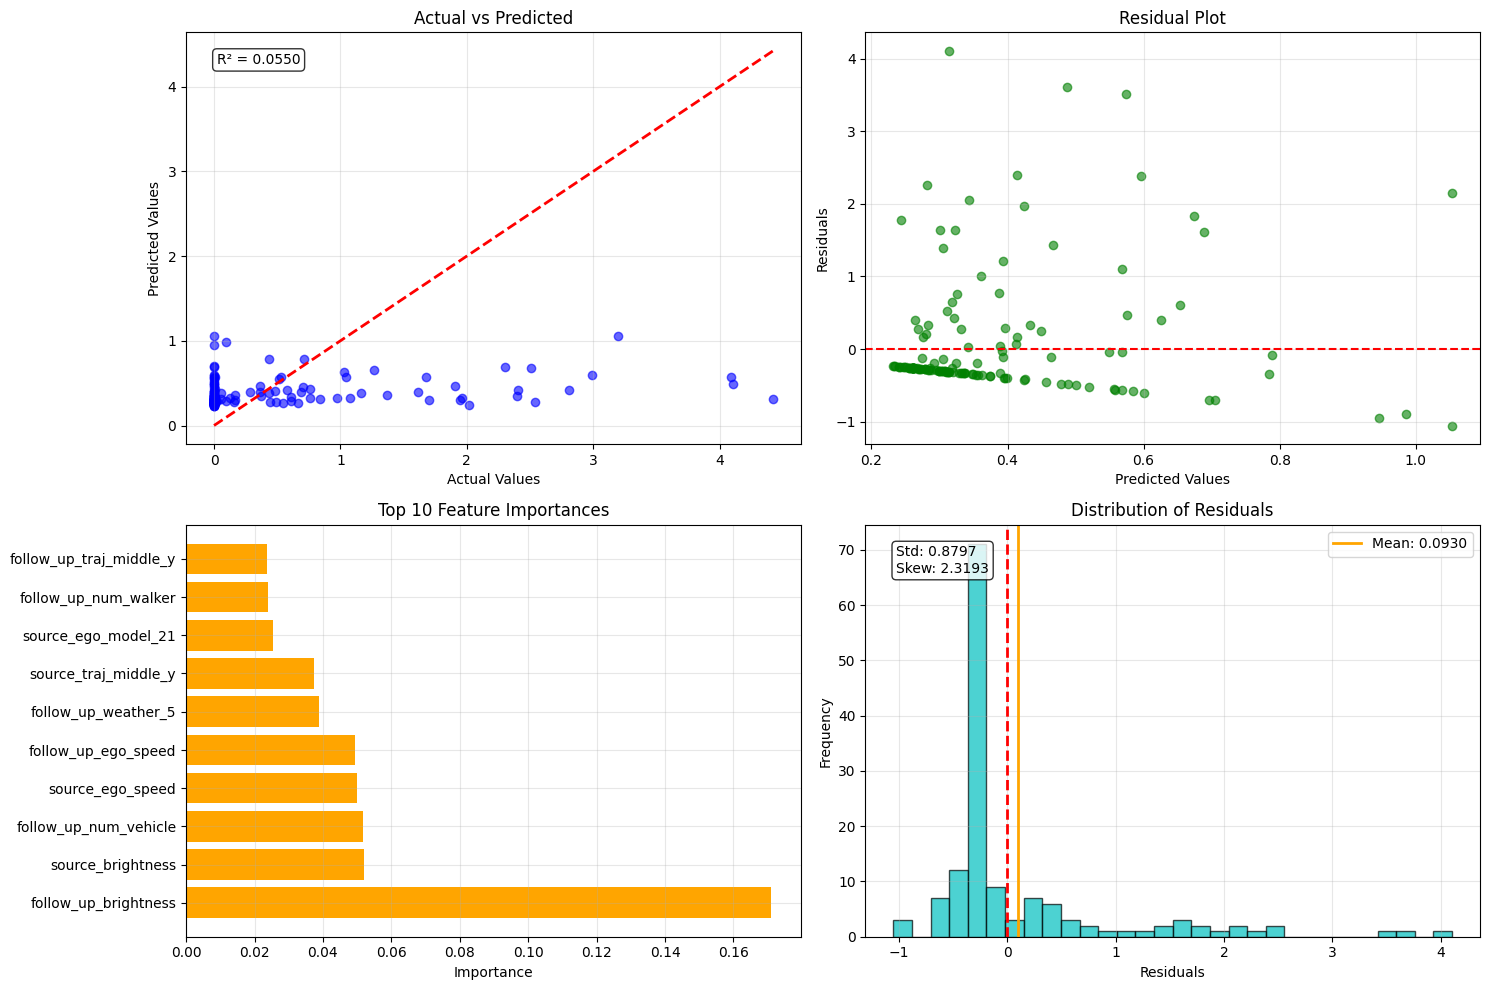

In [7]:
best_model_v2 = model_fit(X, y_v2)

In [10]:
import joblib

best_model = joblib.load("out/exp_results/1750879764425/best_model.pkl")

In [8]:
rulefit = generate_rules(X, y, features, best_model)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("support", ascending=False).style.background_gradient(cmap="viridis")

,rule,type,coef,support,importance
495,source_ego_model_3 <= 0.5 and follow_up_traj_3q_yaw > -269.57991 and source_ego_model_11 <= 0.5 and source_ego_model_14 <= 0.5 and source_ego_model_18 <= 0.5 and source_ego_model_21 <= 0.5 and source_traj_1q_y > -31.37197,rule,0.053951,0.576869,0.026655
494,source_traj_middle_yaw > -337.31679 and source_traj_end_y <= 60.76292 and source_weather_7 <= 0.5 and follow_up_traj_middle_yaw > -382.84421 and follow_up_traj_3q_x <= 40.66365 and follow_up_num_walker <= 6.5 and follow_up_ego_model_5 <= 0.5 and follow_up_ego_model_6 <= 0.5,rule,0.008880,0.548660,0.004419
496,source_traj_3q_x > -4.17033 and source_traj_end_yaw > -540.11612 and source_weather_10 <= 0.5 and follow_up_traj_end_y > -54.59598 and source_ego_model_20 <= 0.5 and follow_up_ego_model_0 <= 0.5 and follow_up_ego_model_6 <= 0.5 and follow_up_ego_model_8 <= 0.5,rule,0.053883,0.504937,0.026940
493,source_traj_3q_z > -0.02773 and source_weather_5 <= 0.5 and source_ego_model_0 <= 0.5 and source_num_static <= 2.5 and source_ego_model_10 <= 0.5 and follow_up_traj_3q_x <= -6.49309 and follow_up_ego_model_2 <= 0.5 and follow_up_ego_model_19 <= 0.5,rule,-0.094733,0.234133,0.040115
497,source_traj_1q_yaw <= -5.82413 and source_traj_middle_x > -75.08949 and source_traj_end_x <= 89.96955 and source_num_vehicle <= 1.5 and source_weather_10 <= 0.5 and follow_up_num_vehicle > 0.5 and source_ego_model_12 <= 0.5 and source_ego_model_14 <= 0.5,rule,0.076160,0.232722,0.032183
498,source_traj_middle_yaw <= 442.12814 and source_traj_3q_z > -0.02131 and source_traj_end_y > -55.16937 and source_ego_model_1 <= 0.5 and follow_up_ego_speed > 2.16373 and follow_up_traj_middle_z <= -1e-05 and source_ego_model_21 <= 0.5 and follow_up_ego_model_9 <= 0.5,rule,0.004312,0.107193,0.001334
492,source_traj_3q_y > -76.54053 and source_traj_end_x > -61.60923 and source_weather_4 <= 0.5 and source_ego_model_2 <= 0.5 and follow_up_traj_3q_x <= -4.88844 and follow_up_traj_3q_x > -35.16118 and source_ego_model_17 <= 0.5 and follow_up_ego_model_6 <= 0.5,rule,-0.105748,0.087447,0.029873
499,source_traj_3q_y <= 29.18793 and source_weather_8 <= 0.5 and source_num_walker <= 3.5 and source_num_static > 0.5 and follow_up_traj_3q_y <= 13.51259 and follow_up_ego_model_0 <= 0.5 and follow_up_ego_model_14 <= 0.5 and source_ego_speed > 4.36414,rule,0.063338,0.045134,0.013149


In [9]:
evaluate_rules(rules, X, y)

2025-06-27 12:35:47,344     INFO  2641635 --- Rule 492: 4.716067880360743 (-0.48495228134293294) (explain.py:314)
2025-06-27 12:35:47,381     INFO  2641635 --- Rule 493: 2.613938438959221 (-0.5907650842658151) (explain.py:314)
2025-06-27 12:35:47,421     INFO  2641635 --- Rule 494: 14.578825256562542 (-0.7539820706727621) (explain.py:314)
2025-06-27 12:35:47,460     INFO  2641635 --- Rule 495: 2.8629113825634427 (-0.65755753497899) (explain.py:314)
2025-06-27 12:35:47,500     INFO  2641635 --- Rule 496: 3.50557073173867 (-0.6340375440075969) (explain.py:314)
2025-06-27 12:35:47,541     INFO  2641635 --- Rule 497: 2.665803864234728 (-0.6754223753597295) (explain.py:314)
2025-06-27 12:35:47,581     INFO  2641635 --- Rule 498: 98.18408733553719 (-0.03419515855614195) (explain.py:314)
2025-06-27 12:35:47,621     INFO  2641635 --- Rule 499: 11.736281490259937 (-0.7325362150786026) (explain.py:314)


In [ ]:
explanation = explain(best_model, X)

In [11]:
scoring(best_model_v1, best_model_v2, X)

4.77022493457301